# Installing Libraries

In [1]:
!pip install psi-io

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import h5py
from pyhdf.SD import SD, SDC
from scipy.ndimage import zoom

import os
import sys
import psi_io
sys.path.append("../../../")

from src.ParamNetwork.psi_reader import read_simulation

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf", "t002.hdf"]
DEFAULT_RESOLUTIONS = ['medium', 'high']
component_list = ["vr", "br", "vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p", "t"]


In [3]:
INSTRUMENT_PATH = '/data/solar_wind_pred_vignesh/hdf/medium/cr1630/kpo_mas_mas_std_0101'

# Reading Simulation Function

In [4]:
def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets

def read_sim(sim_path):
    dataset_names = ["Data-Set-2", "fakeDim0", "fakeDim1", "fakeDim2"]
    component_dict = {k.split('002')[0]:{} for k in FILE_NAMES}
    target_phi, target_theta, target_r = [None]*3
    for file_name in FILE_NAMES:
        data, phi, theta, r = read_hdf(f"{sim_path}/{file_name}", dataset_names) 
        comp = file_name.split('002')[0]
        component_dict[comp] = {
            'data': data[:,:, :],
            'theta': theta,
            'r': r[:],
            'phi': phi,
        }
        if comp == 'vp':
            target_r = np.array([r[1]], dtype=r.dtype) # [30.742662]
            target_theta = theta
            target_phi = phi
            
    return (component_dict, target_r, target_theta, target_phi)

In [5]:
data, r_data, t_data, p_data = read_sim(INSTRUMENT_PATH)

In [6]:
def plot_comparison_plot(component_psi, component_calculated):
    im = [0]*3
    v_min = np.min(component_psi)
    v_max = np.max(component_psi)
    fig, ax = plt.subplots(1,3,figsize=(18,6))
    im[0] = ax[0].imshow(component_psi, vmin=v_min, vmax=v_max)
    im[1] = ax[1].imshow(component_calculated, vmin=v_min, vmax=v_max)
    im[2] = ax[2].imshow(component_calculated - component_psi)
    for i in range(3):
        ax[i].axis('off')
        fig.colorbar(im[i], ax=ax[i], fraction=0.04, pad=0.02)
    ax[0].set_title(r"psi_io remeshing $30R_\odot$")
    ax[1].set_title("manual remeshing $30R_\odot$")
    ax[2].set_title(f"Difference All 0 ({np.all(component_calculated - component_psi == 0)})")
    
    plt.tight_layout()
    plt.show()

# Process $\mathbf{B}_r$
- Interpolate in radial direction

In [7]:
br_data = data['br']['data'].transpose(2,1,0)
br_30r0 = (br_data[0] + br_data[1]) / 2

In [8]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/br002.hdf', model='mas') as mas_reader:
    br, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
    br = np.array(br).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)

In [9]:
def read_br(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/br002.hdf', model='mas') as mas_reader:
        br, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
        br = np.array(br).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    if return_scale:
        return br, r_scale, t_scale, p_scale
    return br

In [10]:
br_fn, r,t,p = read_br(INSTRUMENT_PATH, True)

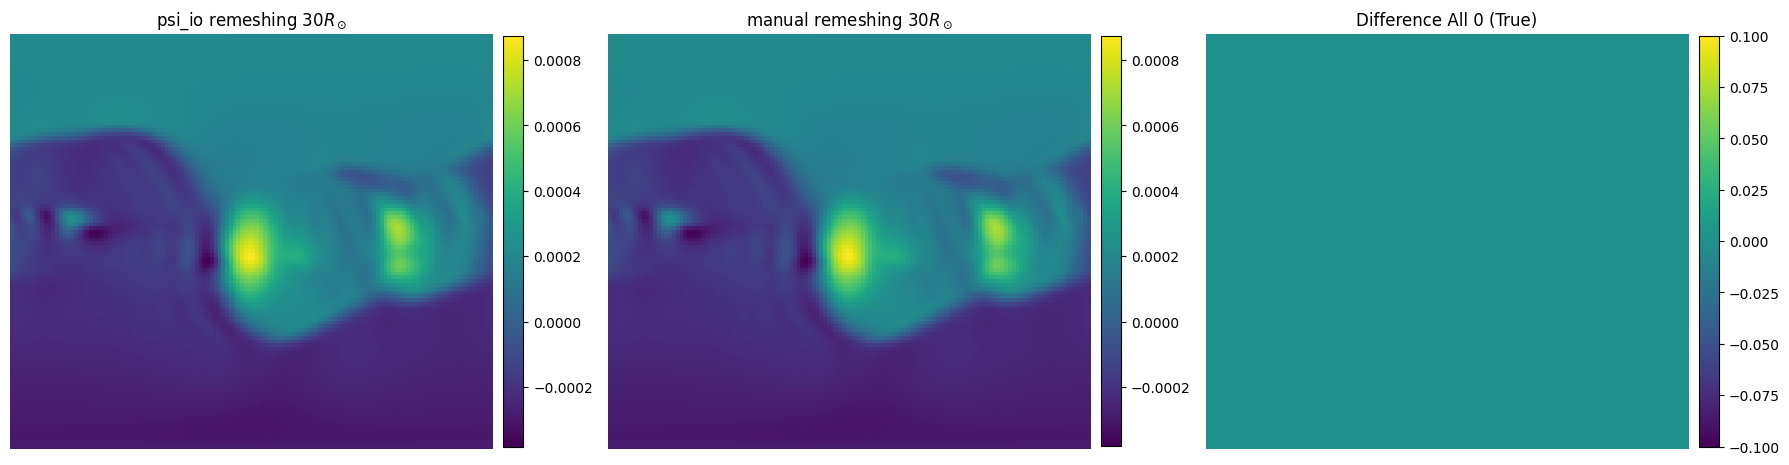

In [11]:
plot_comparison_plot(br_fn[0], br_30r0)

# Processing $\mathbf{B}_\theta$
- Interpolate in $\theta$ direction

In [12]:
bt_data = data['bt']['data'].transpose(2,1,0)
bt_30r0 = (bt_data[0,:-1] + bt_data[0,1:]) / 2
bt_30r0.shape

(110, 128)

In [13]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/bt002.hdf', model='mas') as mas_reader:
    bt, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
    bt = np.array(bt).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)

In [14]:
def read_bt(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/bt002.hdf', model='mas') as mas_reader:
        bt, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
        bt = np.array(bt).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    if return_scale:
        return bt, r_scale, t_scale, p_scale
    return bt

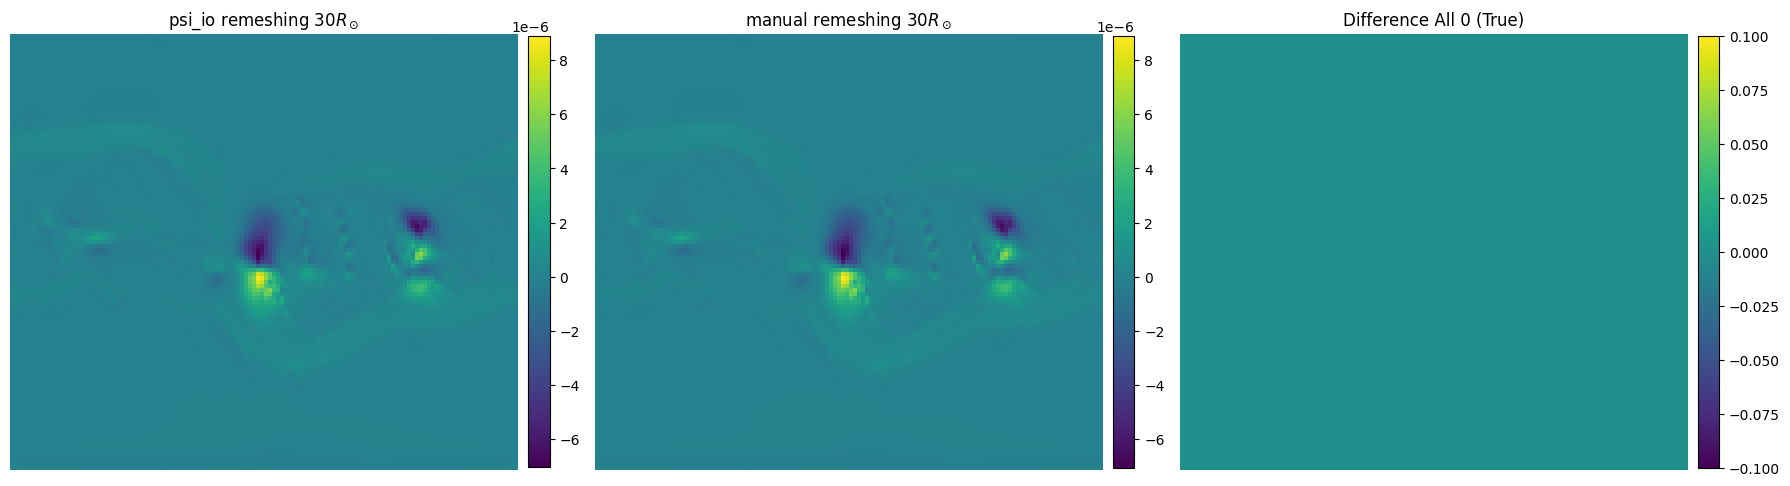

In [15]:
bt, r_scale, t_scale, p_scale = read_bt(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(bt[0], bt_30r0)

# Processing $\mathbf{B}_\phi$

In [16]:
bp_data = data['bp']['data'].transpose(2,1,0)
bp_30r0 = bp_data[0]

In [17]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/bp002.hdf', model='mas') as mas_reader:
    bp, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    bp = np.array(bp).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)

In [18]:
def read_bp(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/bp002.hdf', model='mas') as mas_reader:
        bp, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        bp = np.array(bp).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    if return_scale:
        return bp, r_scale, t_scale, p_scale
    return bp

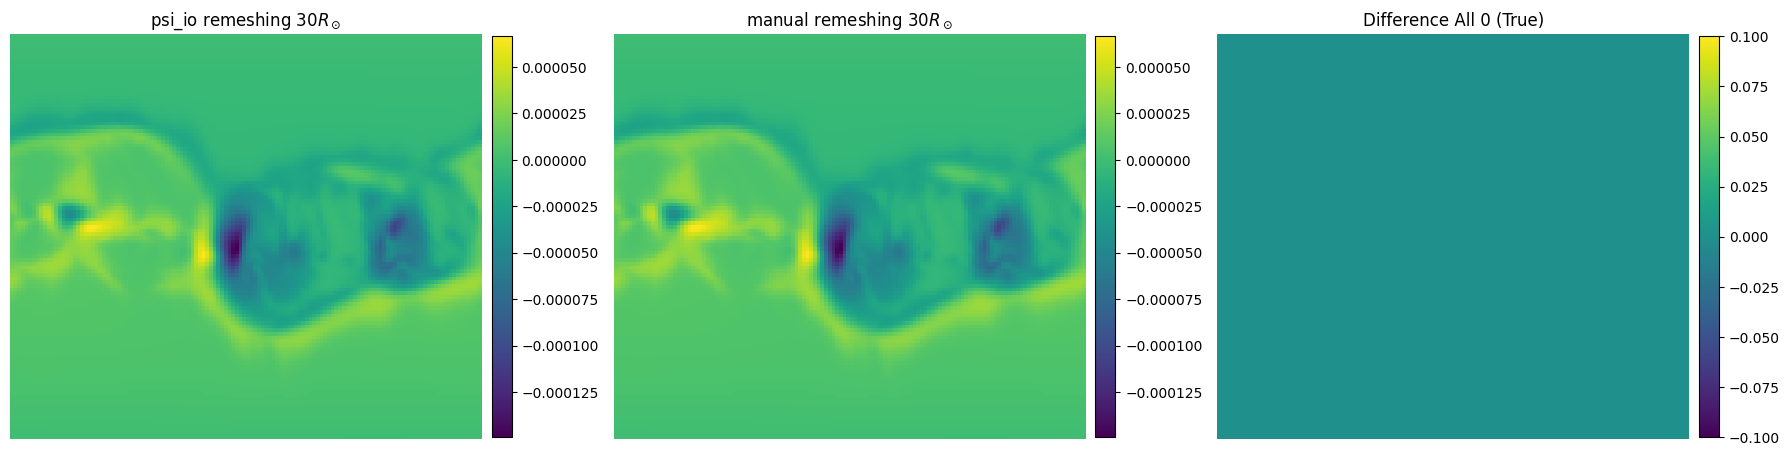

In [19]:
bp, r_scale, t_scale, p_scale = read_bp(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(bp[0], bp_30r0)

# Processing $v_r$

In [20]:
vr_data = data['vr']['data'].transpose(2,1,0)
print(vr_data.shape)
vr_30r0 = (vr_data[0, :-1] + vr_data[0,1:])/2

(140, 111, 128)


In [21]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/vr002.hdf', model='mas') as mas_reader:
    vr, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    vr = np.array(vr).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    vr = (vr[:,:-1] + vr[:,1:])/2
    t_scale = (t_scale[:-1] + t_scale[1:] )/ 2

In [22]:
def read_vr(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/vr002.hdf', model='mas') as mas_reader:
        vr, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        vr = np.array(vr).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        vr = (vr[:,:-1] + vr[:,1:])/2
        t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    if return_scale:
        return vr, r_scale, t_scale, p_scale
    return vr

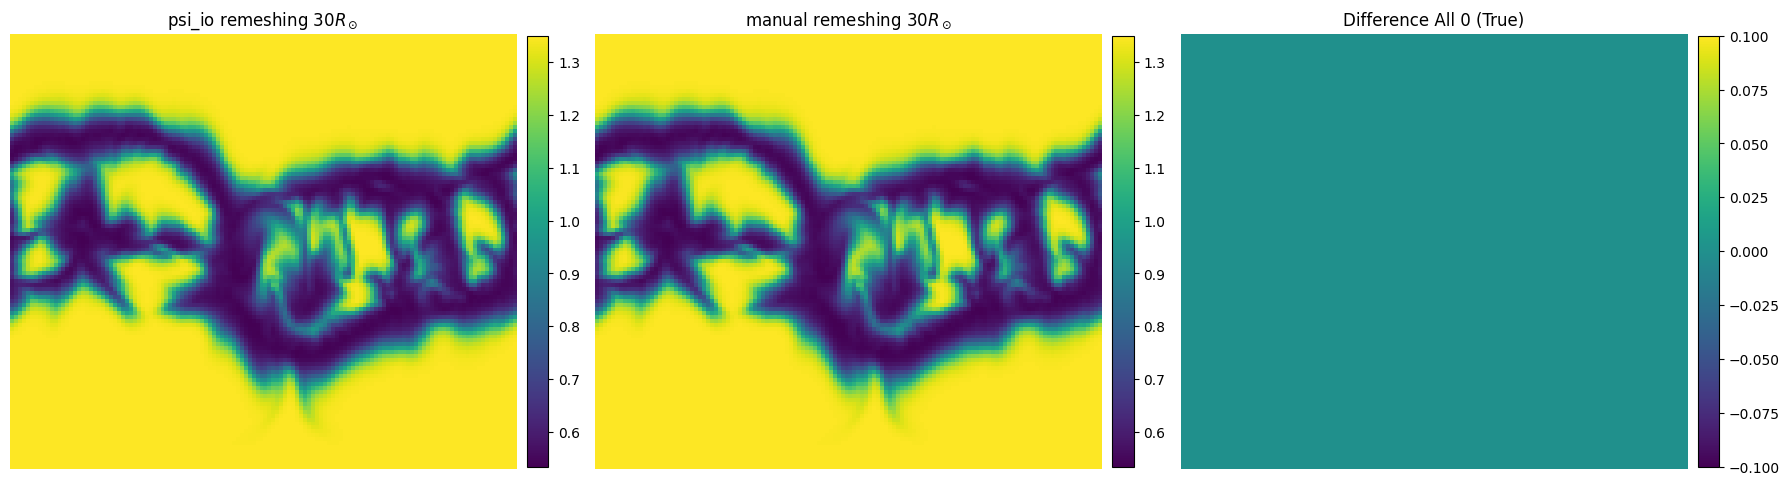

In [23]:
vr, r_scale, t_scale, p_scale = read_vr(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(vr[0], vr_30r0)

# Processing $\mathbf{J}_r$

In [24]:
jr_data = data['jr']['data'].transpose(2,1,0)
print(jr_data.shape)
jr_30r0 = (jr_data[0, :-1] + jr_data[0,1:])/2
print(jr_30r0.shape)

(140, 111, 128)
(110, 128)


In [25]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/jr002.hdf', model='mas') as mas_reader:
    jr, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    jr = np.array(jr).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    jr = (jr[:,:-1] + jr[:,1:])/2
    t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    print(jr.shape)

(140, 110, 128)


In [26]:
def read_jr(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/jr002.hdf', model='mas') as mas_reader:
        jr, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        jr = np.array(jr).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        jr = (jr[:,:-1] + jr[:,1:])/2
        t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    if return_scale:
        return jr, r_scale, t_scale, p_scale
    return jr

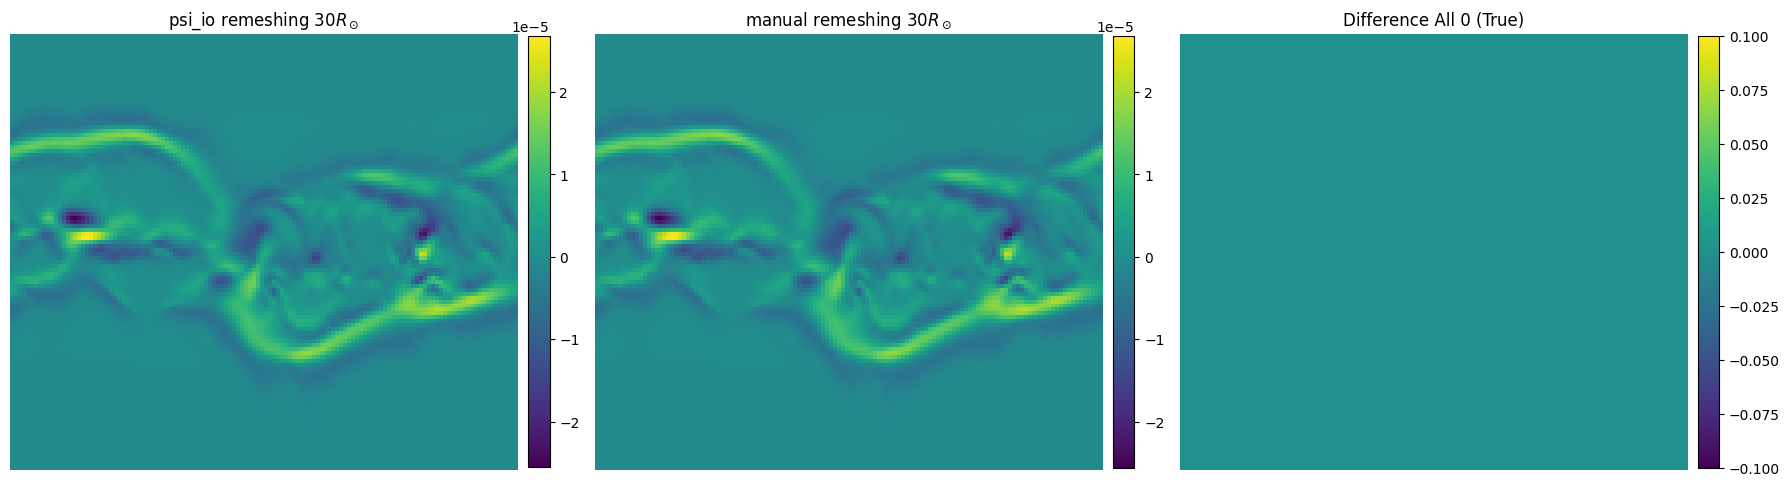

In [27]:
jr, r_scale, t_scale, p_scale = read_jr(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(jr[0], jr_30r0)

# Processing $v_\theta$

- r --> [29.257338, 30.742662, 32.227985]
- t --> [0.        , 0.02882195, 0.0576439 , ... , 3.0839489 , 3.1127708 , 3.1415927 ]
- p --> [0.        , 0.04908739, 0.09817477, ... , 6.1359234 , 6.1850104 , 6.234098  ]
- $V_r [r=29.25R_s] = - V_r [r=30.74R_s]$
- Use either one  

In [28]:
data['vt']['theta']

array([0.        , 0.02882195, 0.0576439 , 0.08646585, 0.1152878 ,
       0.14410976, 0.1729317 , 0.20175366, 0.2305756 , 0.25939757,
       0.2882195 , 0.31704146, 0.3458634 , 0.37468538, 0.40350732,
       0.43232927, 0.4611512 , 0.48997316, 0.51879513, 0.5476171 ,
       0.576439  , 0.60526097, 0.6340829 , 0.66290486, 0.6917268 ,
       0.72054875, 0.74937075, 0.7781927 , 0.80701464, 0.8358366 ,
       0.86465853, 0.8934805 , 0.9223024 , 0.95112437, 0.9799463 ,
       1.0087683 , 1.0375903 , 1.0664122 , 1.0952342 , 1.1240561 ,
       1.152878  , 1.1817    , 1.2105219 , 1.2393439 , 1.2681658 ,
       1.2969878 , 1.3258097 , 1.3546317 , 1.3834536 , 1.4122756 ,
       1.4410975 , 1.4699194 , 1.4987415 , 1.5275635 , 1.5563854 ,
       1.5852073 , 1.6140293 , 1.6428512 , 1.6716732 , 1.7004951 ,
       1.7293171 , 1.758139  , 1.786961  , 1.8157829 , 1.8446048 ,
       1.8734268 , 1.9022487 , 1.9310707 , 1.9598926 , 1.9887146 ,
       2.0175366 , 2.0463586 , 2.0751805 , 2.1040025 , 2.13282

In [29]:
# vt_data = data['vt']['data'].transpose(2,1,0)
# print(vt_data.shape)
# vt_30r0 = (vt_data[1] + vt_data[0])/2
# print(vt_30r0.shape)
# # data['vt']['r']

vt_data = data['vt']['data'].transpose(2,1,0)
print(vt_data.shape)
vt_30r0 = vt_data[1]
print(vt_30r0.shape)

(141, 110, 128)
(110, 128)


In [30]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/vt002.hdf', model='mas') as mas_reader:
    vt, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    vt = np.array(vt).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    # vt = (vt[:-1] + vt[1:])/2
    print(vt.shape)

(141, 110, 128)


In [31]:
def read_vt(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/vt002.hdf', model='mas') as mas_reader:
        vt, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        vt = np.array(vt).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        vt = vt[1:]
        r_scale = r_scale[1:]
    if return_scale:
        return vt, r_scale, t_scale, p_scale
    return vt

[30.742662 32.227985 33.71331  35.19863  36.683956]


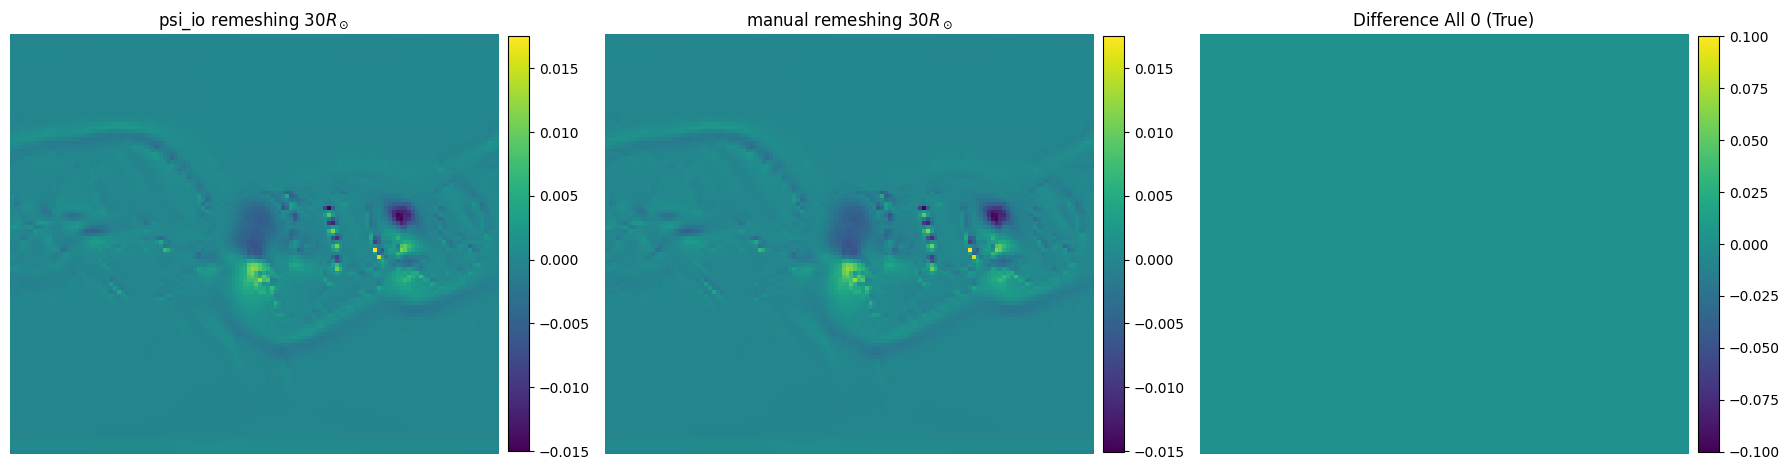

In [32]:
vt, r_scale, t_scale, p_scale = read_vt(INSTRUMENT_PATH, return_scale=True)
print(r_scale[:5])
plot_comparison_plot(vt[0], vt_30r0)

In [33]:
data['vt']['data'][:,:,2] + data['vt']['data'][:,:,1]

array([[-0.00073279, -0.00081389, -0.00019514, ...,  0.00210228,
         0.00075542, -0.00116022],
       [-0.00074762, -0.00082251, -0.0001908 , ...,  0.00210633,
         0.00075991, -0.00116853],
       [-0.00076065, -0.00082939, -0.00018688, ...,  0.00211539,
         0.00076587, -0.00117404],
       ...,
       [-0.00067785, -0.00077742, -0.00020622, ...,  0.00207827,
         0.00075264, -0.00111861],
       [-0.00069786, -0.00079134, -0.00020321, ...,  0.0020937 ,
         0.00075167, -0.00113523],
       [-0.00071619, -0.0008035 , -0.00019942, ...,  0.00209997,
         0.00075262, -0.00114911]], dtype=float32)

In [34]:
def interpolate_cube(data, x_old, y_old, z_old, x_new, y_new, z_new):
    interp_func = RegularGridInterpolator(
        (x_old, y_old, z_old),
        data,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    xg, yg, zg = np.meshgrid(x_new, y_new, z_new, indexing="ij")
    points_new = np.stack([xg.ravel(), yg.ravel(), zg.ravel()], axis=-1)
    data_new_flat = interp_func(points_new)
    data_new = data_new_flat.reshape((len(x_new), len(y_new), len(z_new)))
    return data_new

In [35]:
target_r = (r_scale[1:] + r_scale[:-1])/2
p_scale

array([0.        , 0.04908739, 0.09817477, 0.14726216, 0.19634955,
       0.24543692, 0.2945243 , 0.3436117 , 0.3926991 , 0.44178647,
       0.49087384, 0.5399612 , 0.5890486 , 0.638136  , 0.6872234 ,
       0.7363108 , 0.7853982 , 0.83448553, 0.88357294, 0.93266034,
       0.9817477 , 1.030835  , 1.0799224 , 1.1290098 , 1.1780972 ,
       1.2271847 , 1.276272  , 1.3253593 , 1.3744467 , 1.4235342 ,
       1.4726216 , 1.521709  , 1.5707964 , 1.6198837 , 1.6689711 ,
       1.7180585 , 1.7671459 , 1.8162333 , 1.8653207 , 1.914408  ,
       1.9634954 , 2.0125828 , 2.06167   , 2.1107576 , 2.1598449 ,
       2.2089324 , 2.2580197 , 2.3071072 , 2.3561945 , 2.4052818 ,
       2.4543693 , 2.5034566 , 2.552544  , 2.6016314 , 2.6507187 ,
       2.6998062 , 2.7488935 , 2.797981  , 2.8470683 , 2.8961558 ,
       2.9452431 , 2.9943304 , 3.043418  , 3.0925052 , 3.1415927 ,
       3.19068   , 3.2397673 , 3.2888548 , 3.3379421 , 3.3870296 ,
       3.436117  , 3.4852045 , 3.5342917 , 3.583379  , 3.63246

In [36]:
# data_new.shape

In [37]:
# vt_r0 = data_new.transpose(2,1,0)[2]

In [38]:
# plt.imshow(vt_r0)

# Processing $\mathbf{J}_\theta$

In [39]:
jt_data = data['jt']['data'].transpose(2,1,0)
print(jt_data.shape)
jt_30r0 = (jt_data[1] + jt_data[0])/2
print(jt_30r0.shape)

(141, 110, 128)
(110, 128)


In [40]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/jt002.hdf', model='mas') as mas_reader:
    jt, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    jt = np.array(jt).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    jt = (jt[:-1] + jt[1:])/2
    r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    print(jt.shape)

(140, 110, 128)


In [41]:
def read_jt(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/jt002.hdf', model='mas') as mas_reader:
        jt, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        jt = np.array(jt).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        jt = (jt[:-1] + jt[1:])/2
        r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    if return_scale:
        return jt, r_scale, t_scale, p_scale
    return jt

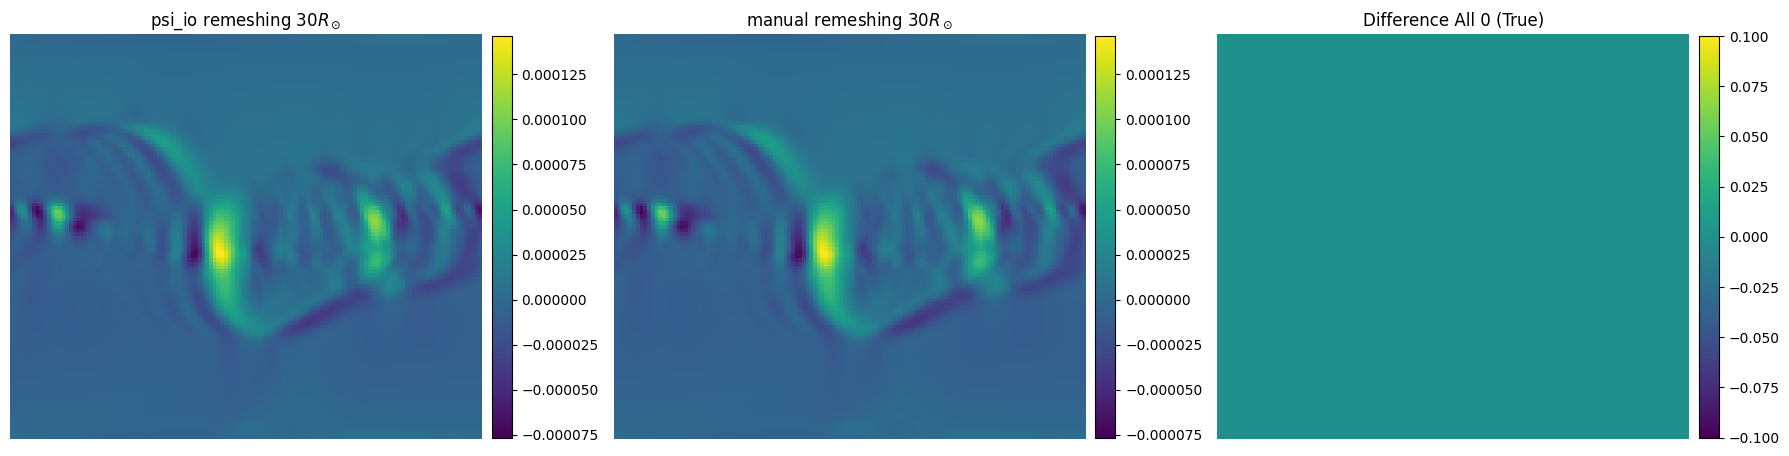

In [42]:
jt, r_scale, t_scale, p_scale = read_jt(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(jt[0], jt_30r0)

# Processing $v_\phi$

In [43]:
vp_data = data['vp']['data'].transpose(2,1,0)
print(vp_data.shape)
vp_30r0 = (vp_data[1,:-1] + vp_data[1,1:])/2
print(vp_30r0.shape)
# data['vt']['r']

(141, 111, 128)
(110, 128)


In [44]:
# (data['vp']['theta'][:-1] + data['vp']['theta'][1:]) / 2
data['vp']['theta']

array([-0.01441098,  0.01441098,  0.04323293,  0.07205488,  0.10087683,
        0.12969878,  0.15852073,  0.18734269,  0.21616463,  0.24498658,
        0.27380854,  0.30263048,  0.33145243,  0.36027437,  0.38909635,
        0.4179183 ,  0.44674024,  0.47556219,  0.50438416,  0.5332061 ,
        0.56202805,  0.59085   ,  0.61967194,  0.6484939 ,  0.67731583,
        0.7061378 ,  0.7349597 ,  0.7637817 ,  0.7926037 ,  0.8214256 ,
        0.85024756,  0.8790695 ,  0.90789145,  0.9367134 ,  0.96553534,
        0.9943573 ,  1.0231793 ,  1.0520012 ,  1.0808232 ,  1.1096451 ,
        1.1384671 ,  1.167289  ,  1.196111  ,  1.2249329 ,  1.2537549 ,
        1.2825768 ,  1.3113987 ,  1.3402207 ,  1.3690426 ,  1.3978646 ,
        1.4266865 ,  1.4555085 ,  1.4843304 ,  1.5131525 ,  1.5419744 ,
        1.5707964 ,  1.5996183 ,  1.6284403 ,  1.6572622 ,  1.6860842 ,
        1.7149061 ,  1.743728  ,  1.77255   ,  1.8013719 ,  1.8301939 ,
        1.8590158 ,  1.8878378 ,  1.9166597 ,  1.9454817 ,  1.97

In [45]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/vp002.hdf', model='mas') as mas_reader:
    vp, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    vp = np.array(vp).transpose(2,1,0)
    print(vp.shape)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    vp = (vp[:,:-1] + vp[:,1:])/2
    t_scale = (t_scale[1:] + t_scale[:-1])/2
    vp = (vp[1:] + vp[:-1])/2
    r_scale = (r_scale[1:] + r_scale[:-1])/2
    print(vp.shape)
    print(r_scale[:5])

(141, 111, 128)
(140, 110, 128)
[30.       31.485325 32.97065  34.45597  35.94129 ]


In [46]:
def read_vp(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/vp002.hdf', model='mas') as mas_reader:
        vp, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        vp = np.array(vp).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        vp = (vp[:,:-1] + vp[:,1:])/2
        t_scale = (t_scale[1:] + t_scale[:-1])/2
        vp = vp[1:]
        r_scale = r_scale[1:]
    if return_scale:
        return vp, r_scale, t_scale, p_scale
    return vp

[30.742662 32.227985 33.71331  35.19863  36.683956]


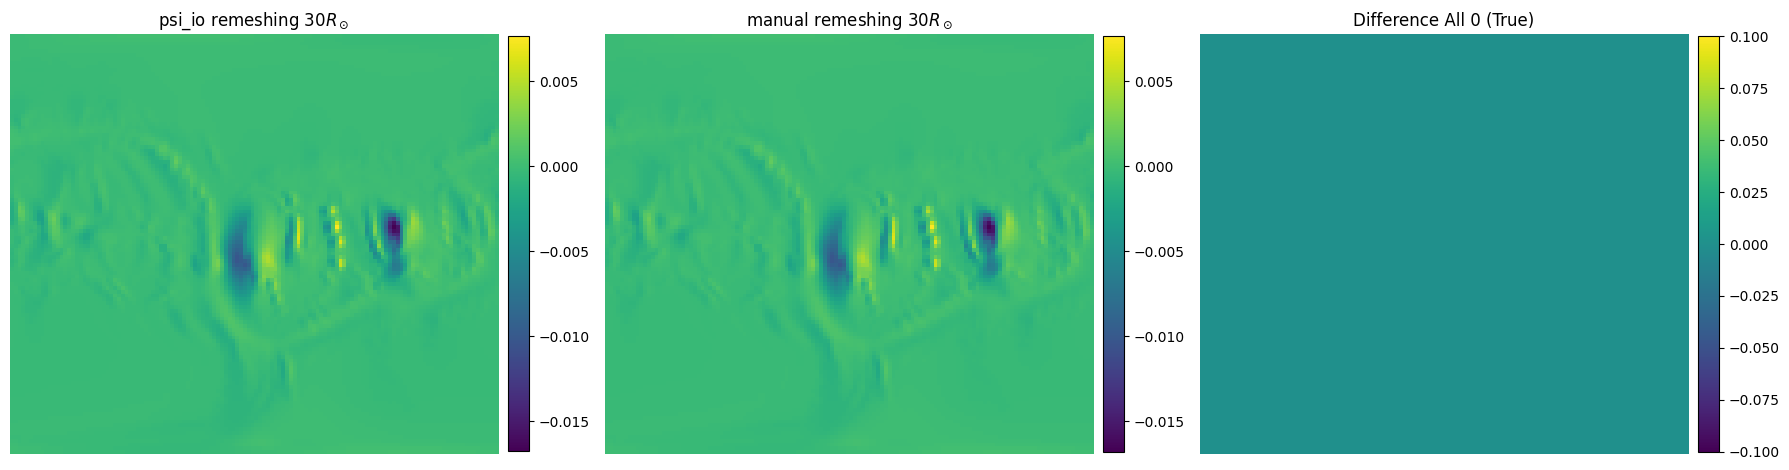

In [47]:
vp, r_scale, t_scale, p_scale = read_vp(INSTRUMENT_PATH, return_scale=True)
print(r_scale[:5])
plot_comparison_plot(vp[0], vp_30r0)

# Processing $\mathbf{J}_\phi$

In [48]:
jp_data = data['jp']['data'].transpose(2,1,0)
print(jp_data.shape)
jp_data = (jp_data[:,:-1] + jp_data[:,1:])/2
jp_30r0 = (jp_data[1] + jp_data[0])/2
print(vp_30r0.shape)

(141, 111, 128)
(110, 128)


In [49]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/jp002.hdf', model='mas') as mas_reader:
    jp, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
    jp = np.array(jp).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    print(jp.shape)

(140, 110, 128)


In [50]:
def read_jp(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/jp002.hdf', model='mas') as mas_reader:
        jp, r_scale, t_scale, p_scale = mas_reader.read(mesh='main', unit=None)
        jp = np.array(jp).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    if return_scale:
        return jp, r_scale, t_scale, p_scale
    return jp

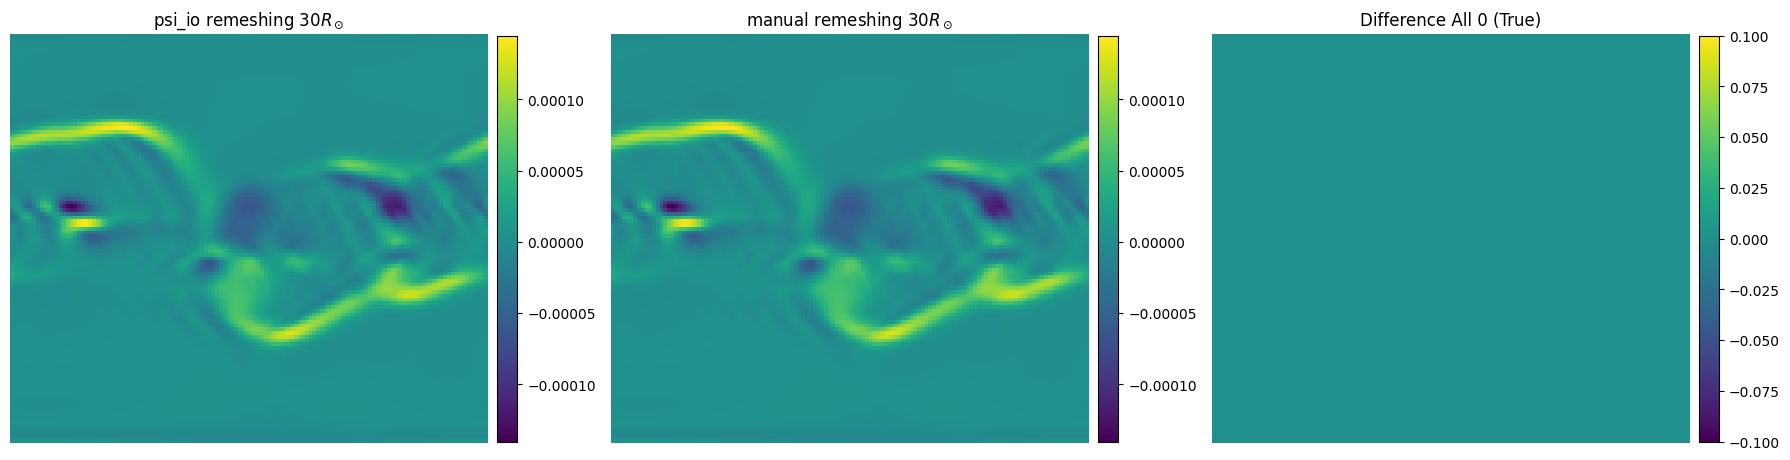

In [51]:
jp, r_scale, t_scale, p_scale = read_jp(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(jp[0], jp_30r0)

 # Processing $\rho$

In [52]:
rho_data = data['rho']['data'].transpose(2,1,0)
print(rho_data.shape)
rho_data = (rho_data[:,:-1] + rho_data[:,1:])/2
rho_30r0 = (rho_data[1] + rho_data[0])/2
print(rho_30r0.shape)

(141, 111, 128)
(110, 128)


In [53]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/rho002.hdf', model='mas') as mas_reader:
    rho, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    rho = np.array(rho).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    print(rho.shape)
    rho = (rho[:,:-1] + rho[:,1:])/2
    t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    rho = (rho[:-1] + rho[1:])/2
    r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    print(rho.shape)

(141, 111, 128)
(140, 110, 128)


In [54]:
def read_rho(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/rho002.hdf', model='mas') as mas_reader:
        rho, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        rho = np.array(rho).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        rho = (rho[:,:-1] + rho[:,1:])/2
        t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
        rho = (rho[:-1] + rho[1:])/2
        r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    if return_scale:
        return rho, r_scale, t_scale, p_scale
    return rho

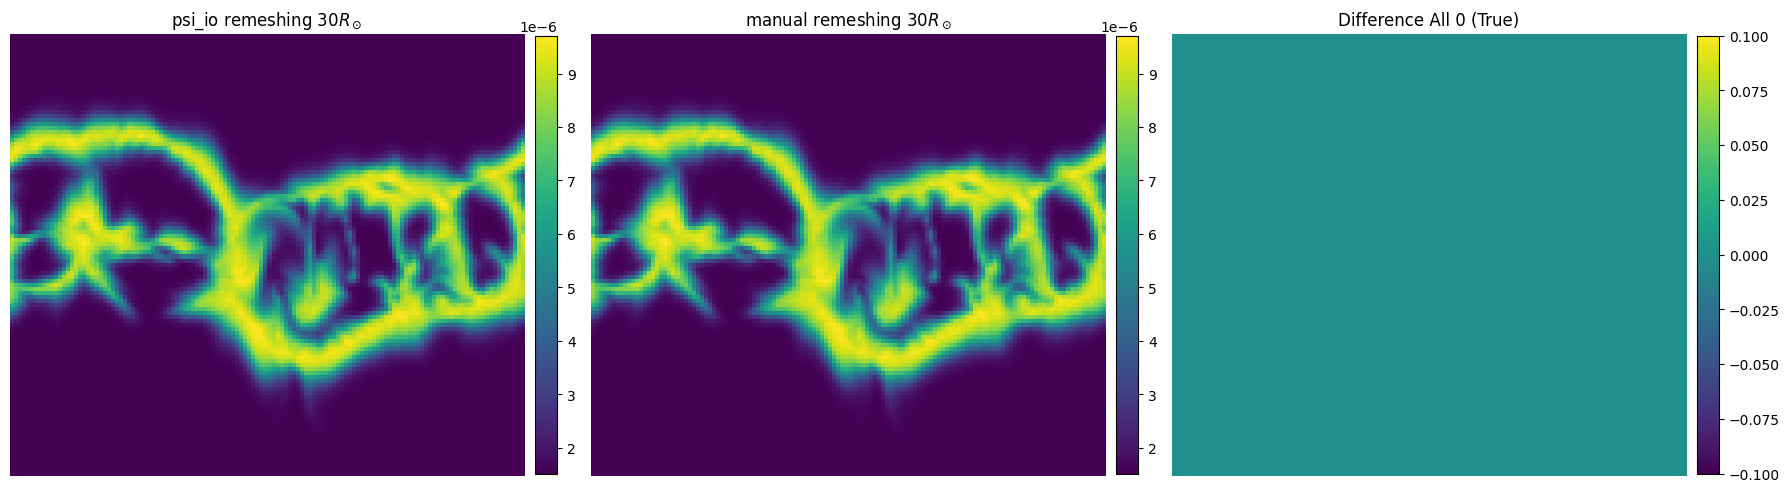

In [55]:
rho, r_scale, t_scale, p_scale = read_rho(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(rho[0], rho_30r0)

# Processing $P$

In [56]:
p_data = data['p']['data'].transpose(2,1,0)
print(p_data.shape)
p_data = (p_data[:,:-1] + p_data[:,1:])/2
p_30r0 = (p_data[1] + p_data[0])/2
print(p_30r0.shape)

(141, 111, 128)
(110, 128)


In [57]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/p002.hdf', model='mas') as mas_reader:
    p, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    p = np.array(p).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    print(p.shape)
    p = (p[:,:-1] + p[:,1:])/2
    t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    p = (p[:-1] + p[1:])/2
    r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    print(p.shape)

(141, 111, 128)
(140, 110, 128)


In [58]:
def read_p(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/p002.hdf', model='mas') as mas_reader:
        p, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        p = np.array(p).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        p = (p[:,:-1] + p[:,1:])/2
        t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
        p = (p[:-1] + p[1:])/2
        r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    if return_scale:
        return p, r_scale, t_scale, p_scale
    return p

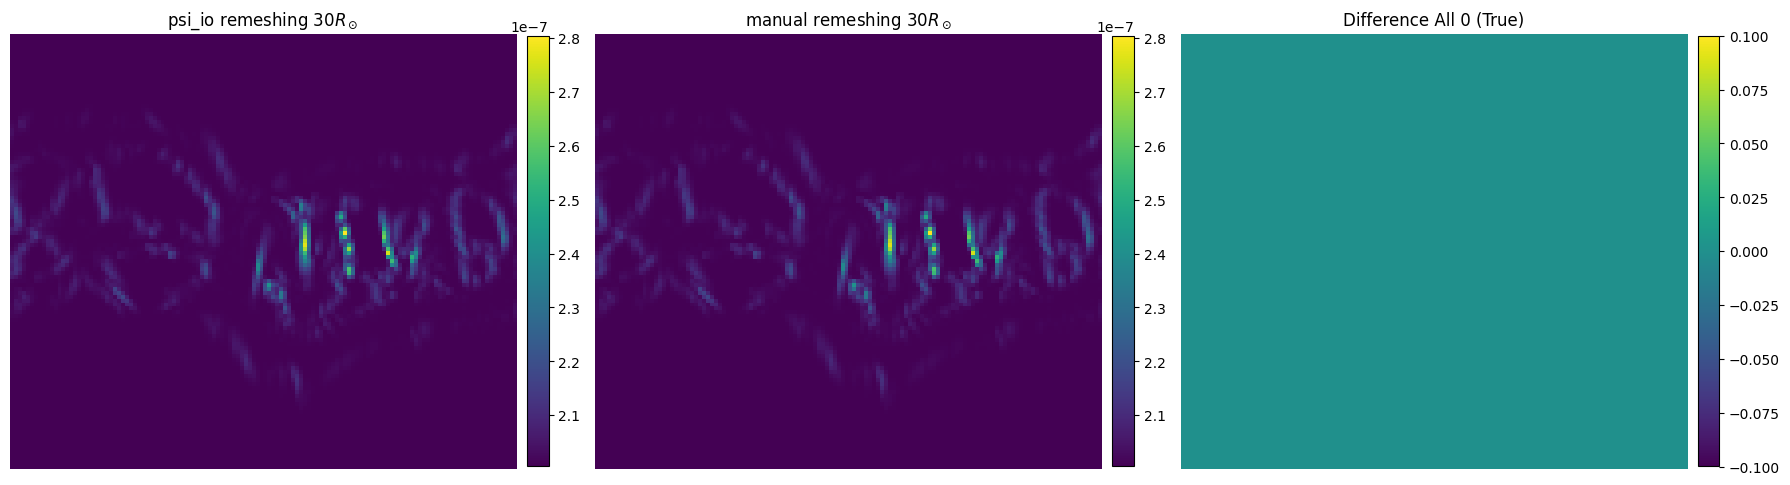

In [59]:
p, r_scale, t_scale, p_scale = read_p(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(p[0], p_30r0)

In [60]:
scale_up = 2

In [61]:
def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)

In [62]:
res, r,t,p = read_simulation(FILE_NAMES, INSTRUMENT_PATH, True)

In [63]:
component_list = [k.split('002')[0] for k in FILE_NAMES]
res, r_scale,t_scale,p_scale = read_simulation(FILE_NAMES, INSTRUMENT_PATH, True)
final_component_arr = [0]*len(component_list)
for idx, component in enumerate(component_list):
    final_component_arr[idx] = res[idx][0]
final_component_arr = np.array(final_component_arr)

if scale_up != 1:
    final_component_arr = enlarge_cube(final_component_arr, scale_up)

# Processing $T$

In [64]:
t_data = data['t']['data'].transpose(2,1,0)
print(p_data.shape)
t_data = (t_data[:,:-1] + t_data[:,1:])/2
t_30r0 = (t_data[1] + t_data[0])/2
print(t_30r0.shape)

(141, 110, 128)
(110, 128)


In [65]:
with psi_io.PsiData(f'{INSTRUMENT_PATH}/t002.hdf', model='mas') as mas_reader:
    t, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
    t = np.array(t).transpose(2,1,0)
    r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
    print(t.shape)
    t = (t[:,:-1] + t[:,1:])/2
    t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
    t = (t[:-1] + t[1:])/2
    r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    print(t.shape)

(141, 111, 128)
(140, 110, 128)


In [66]:
def read_t(instrument_path, return_scale=False):
    with psi_io.PsiData(f'{instrument_path}/t002.hdf', model='mas') as mas_reader:
        t, r_scale, t_scale, p_scale = mas_reader.read(unit=None)
        t = np.array(t).transpose(2,1,0)
        r_scale, t_scale, p_scale = np.array(r_scale), np.array(t_scale), np.array(p_scale)
        t = (t[:,:-1] + t[:,1:])/2
        t_scale = (t_scale[:-1] + t_scale[1:] )/ 2
        t = (t[:-1] + t[1:])/2
        r_scale = (r_scale[:-1] + r_scale[1:] )/ 2
    if return_scale:
        return t, r_scale, t_scale, p_scale
    return t

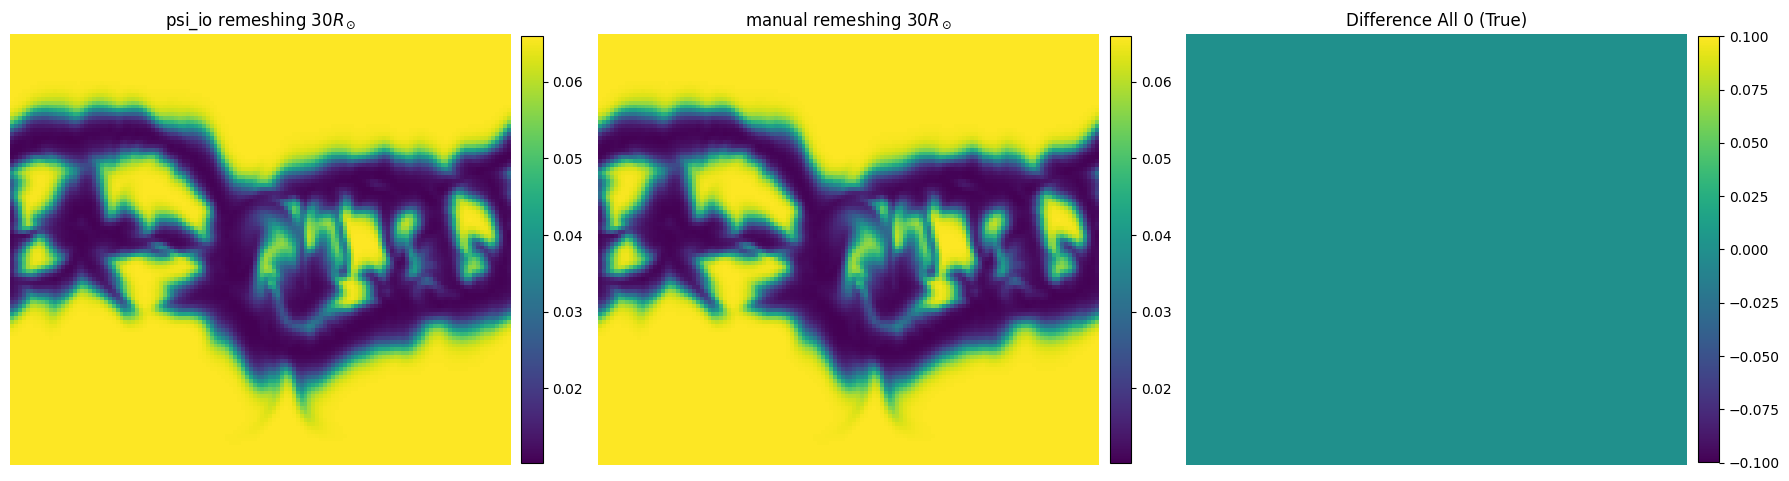

In [67]:
t, r_scale, t_scale, p_scale = read_t(INSTRUMENT_PATH, return_scale=True)
plot_comparison_plot(t[0], t_30r0)

# Clean and write to a File

In [68]:
SAVE_PATH = '/data/solar_wind_pred_vignesh/hdf_cleaned/medium/cr1630/kpo_mas_mas_std_0101'

In [69]:
data, r_scale, t_scale, p_scale = read_simulation(instrument_path=INSTRUMENT_PATH, file_names=FILE_NAMES, return_scale=True)
array = np.array(data)
print(array.shape)
print(component_list)

(12, 140, 110, 128)
['vr', 'br', 'vt', 'vp', 'bt', 'bp', 'jt', 'jp', 'jr', 'rho', 'p', 't']


## Write Helper Function

In [70]:
def save_data(file_path, file_name, component_list, data_array, r_scale=None, t_scale=None, p_scale=None):
    import h5py
    import os
    r_scale = [] if r_scale is None else r_scale
    t_scale = [] if t_scale is None else t_scale
    p_scale = [] if p_scale is None else p_scale
    with h5py.File(os.path.join(file_path, file_name), "w") as f:
        dset = f.create_dataset(
            "data",
            data=data_array,
            compression="gzip",
            compression_opts=4
        )
    
        f.create_dataset(
            "component_list",
            data=np.array(component_list, dtype=h5py.string_dtype("utf-8"))
        )

        f.create_dataset("r_scale", data=np.array(r_scale),compression="gzip",compression_opts=4)
        f.create_dataset("t_scale", data=np.array(t_scale),compression="gzip",compression_opts=4)
        f.create_dataset("p_scale", data=np.array(p_scale),compression="gzip",compression_opts=4)
        f.attrs["description"] = ("MAS solar wind simulation data. Data dimensions are ordered as (component, radius, theta, phi).")

        dset.attrs["description"] = "Multi-component MAS simulation fields. r_scale for vp and vt are from 30.74 R_sun instead of 30 R_sun"
        dset.attrs["dimensions"] = "(component, radius, theta, phi)"
        

In [71]:
save_data(SAVE_PATH, 'mas_data.h5', component_list, data, r_scale, t_scale, p_scale)

## Read Helper Function

In [72]:
def read_data(file_path, file_name):
    import h5py
    import os

    file = os.path.join(file_path, file_name)

    with h5py.File(file, "r") as f:

        # Load data
        data_array = f["data"][:]

        # Load component names as Python strings
        component_list = f["component_list"].asstr()[:].tolist()

        # Load scaling arrays
        r_scale = f["r_scale"][:]
        t_scale = f["t_scale"][:]
        p_scale = f["p_scale"][:]

    return data_array, component_list, r_scale, t_scale, p_scale

In [73]:
read_data, read_components, read_r_scale, read_t_scale, read_p_scale = read_data(
    file_path=SAVE_PATH,
    file_name="mas_data.h5"
)

print(read_data.shape)
print(read_components)
print(read_r_scale.shape)
print(read_t_scale.shape)
print(read_p_scale.shape)

(12, 140, 110, 128)
['vr', 'br', 'vt', 'vp', 'bt', 'bp', 'jt', 'jp', 'jr', 'rho', 'p', 't']
(140,)
(110,)
(128,)


## Sanity check

- make sure written data and read data is same as calculated data

In [74]:
np.all(read_data == data)

True

In [75]:
from src.ParamNetwork.initial_param_dataloader_new import get_cr_dirs, collect_sim_paths

In [76]:
BASE_DIR = '/data/solar_wind_pred_vignesh/hdf/'
cr_dirs = get_cr_dirs(BASE_DIR, resolutions=['medium'])
sims_paths, cr_nums = collect_sim_paths(BASE_DIR, cr_dirs, resolutions=['medium'])

## Running Script

In [77]:
# for idx, sim_path in enumerate(sims_paths):
#     data, r_scale, t_scale, p_scale = read_simulation(instrument_path=sim_path, file_names=FILE_NAMES, return_scale=True)
#     save_sim_path = sim_path.replace('hdf', 'hdf_cleaned')
#     os.makedirs(save_sim_path, exist_ok=True)
#     save_data(save_sim_path, 'mas_data.h5', component_list, data, r_scale, t_scale, p_scale)

# Getting Library Mesh data

In [78]:
component_list = ["vr", "br", "vt", "vp", "bt", "bp","jt", "jp", "jr", "rho", "p"]

grid_locations = {
    "vr":  ["main", "half", "half"],
    "br":  ["half", "main", "main"],
    "vt":  ["half", "main", "half"],
    "vp":  ["half", "half", "main"],
    "bt":  ["main", "half", "main"],
    "bp":  ["main", "main", "half"],
    "jt":  ["half", "main", "half"],
    "jp":  ["half", "half", "main"],
    "jr":  ["main", "half", "half"],
    "rho": ["half", "half", "half"],
    "p":   ["half", "half", "half"],
}

grid_df = pd.DataFrame.from_dict(grid_locations,orient="index",columns=["r", "theta", "phi"])
grid_df

,r,theta,phi
vr,main,half,half
br,half,main,main
vt,half,main,half
vp,half,half,main
bt,main,half,main
bp,main,main,half
jt,half,main,half
jp,half,half,main
jr,main,half,half
rho,half,half,half


# Getting Helio data

In [79]:
INSTRUMENT_PATH = '/data/solar_wind_pred_vignesh/hdf/medium/cr1630/kpo_mas_mas_std_0101'
helio_data, r_data, t_data, p_data = read_sim(INSTRUMENT_PATH)

In [80]:
print('='*25, 'MAIN mesh locations', '='*35)
print('R======>',helio_data['vr']['r'][:3], "....", helio_data['vr']['r'][-3:])
print('THETA==>',helio_data['br']['theta'][:3], ".....", helio_data['br']['theta'][-3:])
print('PHI====>',helio_data['br']['phi'][:3], ".....", helio_data['br']['phi'][-3:])
print('='*81)

========================= MAIN mesh locations ===================================
R======> [30.       31.485323 32.970646] .... [233.48935 234.97467 236.46   ]
THETA==> [0.         0.02882195 0.0576439 ] ..... [3.0839489 3.1127708 3.1415927]
PHI====> [0.         0.04908739 0.09817477] ..... [6.1359234 6.1850104 6.234098 ]


In [81]:
print('='*25, 'HALF mesh locations', '='*40)
print('R======>',helio_data['p']['r'][:3], "....", helio_data['p']['r'][-3:])
print('THETA==>',helio_data['p']['theta'][:3], ".....", helio_data['p']['theta'][-3:])
print('PHI====>',helio_data['p']['phi'][:3], ".....", helio_data['p']['phi'][-3:])
print('='*86)

========================= HALF mesh locations ========================================
R======> [29.257338 30.742662 32.227985] .... [234.23201 235.71733 237.20267]
THETA==> [-0.01441098  0.01441098  0.04323293] ..... [3.0983598 3.1271818 3.1560037]
PHI====> [0.         0.04908739 0.09817477] ..... [6.1359234 6.1850104 6.234098 ]


In [82]:
for c in component_list:
    print(f"{c.upper()} =>\t R: {helio_data[c]['r'].shape[0]} \t Theta: {helio_data[c]['theta'].shape[0]}\t Phi: {helio_data[c]['phi'].shape[0]}")

VR =>	 R: 140 	 Theta: 111	 Phi: 128
BR =>	 R: 141 	 Theta: 110	 Phi: 128
VT =>	 R: 141 	 Theta: 110	 Phi: 128
VP =>	 R: 141 	 Theta: 111	 Phi: 128
BT =>	 R: 140 	 Theta: 111	 Phi: 128
BP =>	 R: 140 	 Theta: 110	 Phi: 128
JT =>	 R: 141 	 Theta: 110	 Phi: 128
JP =>	 R: 141 	 Theta: 111	 Phi: 128
JR =>	 R: 140 	 Theta: 111	 Phi: 128
RHO =>	 R: 141 	 Theta: 111	 Phi: 128
P =>	 R: 141 	 Theta: 111	 Phi: 128


In [83]:
HELIO_MAP = {
    'r': {140: 'main', 141: 'half'},
    'theta': {110: 'main', 111: 'half'},
    'phi': {128: 'main', 129: 'half'}
}

In [84]:
helio_dict ={}
DIMS = ['r', 'theta', 'phi']
for c in component_list:
    res = {}
    for d in DIMS:
        try:
            res[f'{d}'] = HELIO_MAP[d][helio_data[c][d].shape[0]]
        except:
            print(c,d, helio_data[c][d].shape, HELIO_MAP[d])
    helio_dict[c] = res
helio_df =pd.DataFrame.from_dict(helio_dict, orient='index')
helio_df

,r,theta,phi
vr,main,half,main
br,half,main,main
vt,half,main,main
vp,half,half,main
bt,main,half,main
bp,main,main,main
jt,half,main,main
jp,half,half,main
jr,main,half,main
rho,half,half,main


In [85]:
helio_df == grid_df

,r,theta,phi
vr,True,True,False
br,True,True,True
vt,True,True,False
vp,True,True,True
bt,True,True,True
bp,True,True,False
jt,True,True,False
jp,True,True,True
jr,True,True,False
rho,True,True,False


# Cross verification with corona

In [86]:
INSTRUMENT_PATH = '/data/solar_wind_pred_vignesh/corona/medium/cr1630/kpo_mas_mas_std_0101'

In [87]:
corona_data, r_data, t_data, p_data = read_sim(INSTRUMENT_PATH)

In [88]:
print('='*25, 'MAIN mesh locations', '='*35)
print('R======>',corona_data['vr']['r'][:3], "....", corona_data['vr']['r'][-3:])
print('THETA==>',corona_data['br']['theta'][:3], ".....", corona_data['br']['theta'][-3:])
print('PHI====>',corona_data['br']['phi'][:3], ".....", corona_data['br']['phi'][-3:])
print('='*81)

========================= MAIN mesh locations ===================================
R======> [1.        1.0101368 1.0205036] .... [26.076332 27.997389 30.      ]
THETA==> [0.         0.04316993 0.08607038] ..... [3.0555222 3.0984228 3.1415927]
PHI====> [0.        0.0494739 0.0989478] ..... [6.1842375 6.2337112 6.2831855]


In [89]:
print('='*25, 'HALF mesh locations', '='*40)
print('R======>',corona_data['p']['r'][:3], "....", corona_data['p']['r'][-3:])
print('THETA==>',corona_data['p']['theta'][:3], ".....", corona_data['p']['theta'][-3:])
print('PHI====>',corona_data['p']['phi'][:3], ".....", corona_data['p']['phi'][-3:])
print('='*86)

========================= HALF mesh locations ========================================
R======> [0.9949316 1.0050684 1.0153202] .... [27.03686  28.998693 31.001307]
THETA==> [-0.02158496  0.02158496  0.06462015] ..... [3.0769725 3.1200078 3.1631777]
PHI====> [-0.02473695  0.02473695  0.07421085] ..... [6.2089744 6.258448  6.3079224]


In [90]:
for c in component_list:
    print(f"{c.upper()} =>\t R: {corona_data[c]['r'].shape[0]} \t Theta: {corona_data[c]['theta'].shape[0]}\t Phi: {corona_data[c]['phi'].shape[0]}")

VR =>	 R: 100 	 Theta: 101	 Phi: 129
BR =>	 R: 101 	 Theta: 100	 Phi: 128
VT =>	 R: 101 	 Theta: 100	 Phi: 129
VP =>	 R: 101 	 Theta: 101	 Phi: 128
BT =>	 R: 100 	 Theta: 101	 Phi: 128
BP =>	 R: 100 	 Theta: 100	 Phi: 129
JT =>	 R: 101 	 Theta: 100	 Phi: 129
JP =>	 R: 101 	 Theta: 101	 Phi: 128
JR =>	 R: 100 	 Theta: 101	 Phi: 129
RHO =>	 R: 101 	 Theta: 101	 Phi: 129
P =>	 R: 101 	 Theta: 101	 Phi: 129


In [91]:
CORONA_MAP = {
    'r': {100: 'main', 101: 'half'},
    'theta': {100: 'main', 101: 'half'},
    'phi': {128: 'main', 129: 'half'}
}

In [92]:
corona_dict ={}
DIMS = ['r', 'theta', 'phi']
for c in ['vr', 'br'] + component_list:
    res = {}
    for d in DIMS:
        try:
            res[f'{d}'] = CORONA_MAP[d][corona_data[c][d].shape[0]]
        except:
            print(c,d, corona_data[c][d].shape, CORONA_MAP[d])
    corona_dict[c] = res

In [93]:
import pandas as pd

In [94]:
corona_df =pd.DataFrame.from_dict(corona_dict, orient='index')
corona_df

,r,theta,phi
vr,main,half,half
br,half,main,main
vt,half,main,half
vp,half,half,main
bt,main,half,main
bp,main,main,half
jt,half,main,half
jp,half,half,main
jr,main,half,half
rho,half,half,half


In [95]:
corona_df == grid_df

,r,theta,phi
vr,True,True,True
br,True,True,True
vt,True,True,True
vp,True,True,True
bt,True,True,True
bp,True,True,True
jt,True,True,True
jp,True,True,True
jr,True,True,True
rho,True,True,True


# Verdict

- Staggered mesh in PHI direction is applicable for CORONA data
- Staggered mesh in PHI direction is not applicable for HELIO data
- Considering this, the cleaned data is correct, except for radial direction in vt and vp where it is half mesh and goes from 30.75...
    - To get the main mesh in radial direction do (vr[:-1] + vr[1:])/2 to get values from [31.5R_s, ..., 1AU] and concatenate it with a array of zeros for 30 solar radii